# 3-Way GNN: Drug Triplet Interaction Prediction
**Owner:** Sharise  
**Project:** CompoundIQ / PharmAI  
**Course:** ITAI 2376 Deep Learning  

---
## What This Does
Instead of predicting interactions between **2 drugs**, this model predicts interactions between **3 drugs at once** (a triplet).  
Given Drug A + Drug B + Drug C, the model outputs: **0 = no interaction, 1 = interaction exists**

### Data:
- `parquet 1.parquet` — 4,500 training triplets
- `parquet 2.parquet` — 4,500 validation triplets  
- `parquet 3.parquet` — 21,000 test triplets

## Step 1: Install & Import

In [1]:
!pip install torch torch-geometric -q
!pip install pandas numpy matplotlib seaborn scikit-learn -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded!')
print(f'PyTorch version: {torch.__version__}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.3 MB/s eta 0:00:00
All libraries loaded!
PyTorch version: 2.10.0+cpu


## Step 2: Load the Real DrugBank Parquet Files

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Load all 3 parquet files
df_train = pd.read_parquet('/content/drive/MyDrive/parquet 1.parquet')
df_val   = pd.read_parquet('/content/drive/MyDrive/parquet 2.parquet')
df_test  = pd.read_parquet('/content/drive/MyDrive/parquet 3.parquet')

print(f'Training set:   {df_train.shape[0]:,} triplets')
print(f'Validation set: {df_val.shape[0]:,} triplets')
print(f'Test set:       {df_test.shape[0]:,} triplets')
print(f'Total:          {df_train.shape[0] + df_val.shape[0] + df_test.shape[0]:,} triplets')
print(f'\nFeatures per triplet: {df_train.shape[1]}')
print(f'\nClass balance (train):')
print(df_train['triplet_label'].value_counts())

Mounted at /content/drive
Training set:   4,500 triplets
Validation set: 4,500 triplets
Test set:       21,000 triplets
Total:          30,000 triplets

Features per triplet: 39

Class balance (train):
triplet_label
0    2250
1    2250
Name: count, dtype: int64


## Step 3: Prepare Features

In [3]:
# Features to use for each drug in the triplet
DRUG_FEATURES = [
    'total_interactions',
    'n_unique_cyp',
    'degree_centrality',
    'betweenness_centrality',
    'severity_mean',
    'max_similarity_to_reference',
    'safety_complexity_score',
    'has_valid_smiles'
]

# Triplet-level features
TRIPLET_FEATURES = [
    'triplet_total_interactions_sum',
    'triplet_n_unique_cyp_sum',
    'triplet_degree_centrality_mean',
    'triplet_betweenness_centrality_mean',
    'triplet_severity_mean',
    'triplet_max_similarity',
    'triplet_safety_complexity_sum',
    'triplet_valid_smiles_count'
]

def build_feature_matrix(df):
    """Build feature matrix: Drug A features + Drug B features + Drug C features + triplet features"""
    feat_a = df[[f + '_a' for f in DRUG_FEATURES]].values
    feat_b = df[[f + '_b' for f in DRUG_FEATURES]].values
    feat_c = df[[f + '_c' for f in DRUG_FEATURES]].values
    feat_t = df[TRIPLET_FEATURES].values
    # Concatenate all features: 8+8+8+8 = 32 features total
    return np.concatenate([feat_a, feat_b, feat_c, feat_t], axis=1)

X_train = build_feature_matrix(df_train)
X_val   = build_feature_matrix(df_val)
X_test  = build_feature_matrix(df_test)

y_train = df_train['triplet_label'].values
y_val   = df_val['triplet_label'].values
y_test  = df_test['triplet_label'].values

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f'Feature matrix shape: {X_train.shape}  → [{X_train.shape[0]} triplets, {X_train.shape[1]} features]')
print(f'Features breakdown: 8 (Drug A) + 8 (Drug B) + 8 (Drug C) + 8 (triplet) = 32 total')

Feature matrix shape: (4500, 32)  → [4500 triplets, 32 features]
Features breakdown: 8 (Drug A) + 8 (Drug B) + 8 (Drug C) + 8 (triplet) = 32 total


## Step 4: Build the 3-Way GNN Model

### Architecture:
```
Drug A features (8) ─┐
Drug B features (8) ─┼─► Node Encoder ─► Message Passing (GAT) ─► Pool ─► Combined (256)
Drug C features (8) ─┘                                                         │
Triplet features (8) ──────────────────────────────────────────────────────────┤
                                                                                ▼
                                                                    Classifier MLP
                                                                                │
                                                              Interaction Probability (0-1)
```

In [4]:
class ThreeWayGNN(nn.Module):
    """
    3-Way GNN for drug triplet interaction prediction.

    Takes features for 3 drugs + triplet-level features.
    Uses message passing between the 3 drug nodes.
    Outputs interaction probability (0-1).
    """
    def __init__(self, drug_feat_dim=8, triplet_feat_dim=8, hidden_dim=64, output_dim=1):
        super(ThreeWayGNN, self).__init__()

        # Shared drug encoder — same weights for all 3 drugs
        self.drug_encoder = nn.Sequential(
            nn.Linear(drug_feat_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

        # Message passing — drugs share information with each other
        # Drug A attends to Drug B and C, etc.
        self.message_passing = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=4,
            dropout=0.2,
            batch_first=True
        )

        # Triplet feature encoder
        self.triplet_encoder = nn.Sequential(
            nn.Linear(triplet_feat_dim, hidden_dim),
            nn.ReLU()
        )

        # Final classifier
        # Input: 3 drug embeddings (pooled) + triplet features = 64*2 + 64 = 192
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 3 + hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, output_dim),
            nn.Sigmoid()
        )

    def forward(self, drug_a, drug_b, drug_c, triplet_feats):
        # Encode each drug independently (shared encoder)
        emb_a = self.drug_encoder(drug_a)  # [B, 64]
        emb_b = self.drug_encoder(drug_b)  # [B, 64]
        emb_c = self.drug_encoder(drug_c)  # [B, 64]

        # Stack into sequence for attention: [B, 3, 64]
        drug_seq = torch.stack([emb_a, emb_b, emb_c], dim=1)

        # Message passing via self-attention (drugs attend to each other)
        attended, _ = self.message_passing(drug_seq, drug_seq, drug_seq)

        # Pool attended representations
        pooled = attended.mean(dim=1)  # [B, 64]

        # Encode triplet features
        triplet_emb = self.triplet_encoder(triplet_feats)  # [B, 64]

        # Concatenate everything
        combined = torch.cat([emb_a, emb_b, emb_c, triplet_emb], dim=1)  # [B, 256]

        return self.classifier(combined).squeeze()  # [B]


# Initialize model
model = ThreeWayGNN(drug_feat_dim=8, triplet_feat_dim=8, hidden_dim=64)
total_params = sum(p.numel() for p in model.parameters())
print('3-Way GNN Model:')
print(model)
print(f'\nTotal parameters: {total_params:,}')

3-Way GNN Model:
ThreeWayGNN(
  (drug_encoder): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): ReLU()
  )
  (message_passing): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
  )
  (triplet_encoder): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
  )
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

Total parameters: 63,297


## Step 5: Create PyTorch Dataset

In [5]:
class DrugTripletDataset(Dataset):
    """PyTorch Dataset for drug triplets."""
    def __init__(self, X, y):
        # Split features back into drug A, B, C and triplet features
        self.drug_a      = torch.tensor(X[:, 0:8],   dtype=torch.float32)
        self.drug_b      = torch.tensor(X[:, 8:16],  dtype=torch.float32)
        self.drug_c      = torch.tensor(X[:, 16:24], dtype=torch.float32)
        self.triplet     = torch.tensor(X[:, 24:32], dtype=torch.float32)
        self.labels      = torch.tensor(y,           dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.drug_a[idx], self.drug_b[idx], self.drug_c[idx], self.triplet[idx], self.labels[idx]


# Create datasets and loaders
train_dataset = DrugTripletDataset(X_train, y_train)
val_dataset   = DrugTripletDataset(X_val,   y_val)
test_dataset  = DrugTripletDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Test batches:  {len(test_loader)}')

Train batches: 71
Val batches:   71
Test batches:  329


## Step 6: Train the Model

In [6]:
# Calculate class weights to handle imbalance
pos_weight = torch.tensor([(y_train == 0).sum() / (y_train == 1).sum()], dtype=torch.float32)
print(f'Class weight for positive class: {pos_weight.item():.3f}')

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.BCELoss()
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

train_losses, val_losses, val_aucs = [], [], []
EPOCHS = 15

print(f'Training for {EPOCHS} epochs...')
print(f'{"Epoch":<8} {"Train Loss":<14} {"Val Loss":<14} {"Val AUC"}')
print('-' * 50)

for epoch in range(1, EPOCHS + 1):
    # --- Training ---
    model.train()
    total_loss = 0
    for drug_a, drug_b, drug_c, triplet, labels in train_loader:
        optimizer.zero_grad()
        preds = model(drug_a, drug_b, drug_c, triplet)
        loss  = criterion(preds, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_train_loss = total_loss / len(train_loader)

    # --- Validation ---
    model.eval()
    val_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for drug_a, drug_b, drug_c, triplet, labels in val_loader:
            preds = model(drug_a, drug_b, drug_c, triplet)
            loss  = criterion(preds, labels)
            val_loss += loss.item()
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_auc = roc_auc_score(all_labels, all_preds)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    val_aucs.append(val_auc)
    scheduler.step()

    print(f'{epoch:<8} {avg_train_loss:<14.4f} {avg_val_loss:<14.4f} {val_auc:.4f}')

print('\nTraining complete!')

Class weight for positive class: 1.000
Training for 15 epochs...
Epoch    Train Loss     Val Loss       Val AUC
--------------------------------------------------
1        0.2169         0.0521         0.9989
2        0.0559         0.0555         0.9995
3        0.0540         0.0371         0.9995
4        0.0401         0.0297         0.9997
5        0.0306         0.0339         0.9998
6        0.0310         0.0233         0.9998
7        0.0258         0.0240         0.9998
8        0.0225         0.0328         0.9998
9        0.0219         0.0246         0.9998
10       0.0193         0.0197         0.9999
11       0.0159         0.0196         0.9999
12       0.0203         0.0174         0.9999
13       0.0171         0.0181         0.9998
14       0.0178         0.0174         0.9999
15       0.0169         0.0194         0.9999

Training complete!


## Step 7: Plot Training Curves

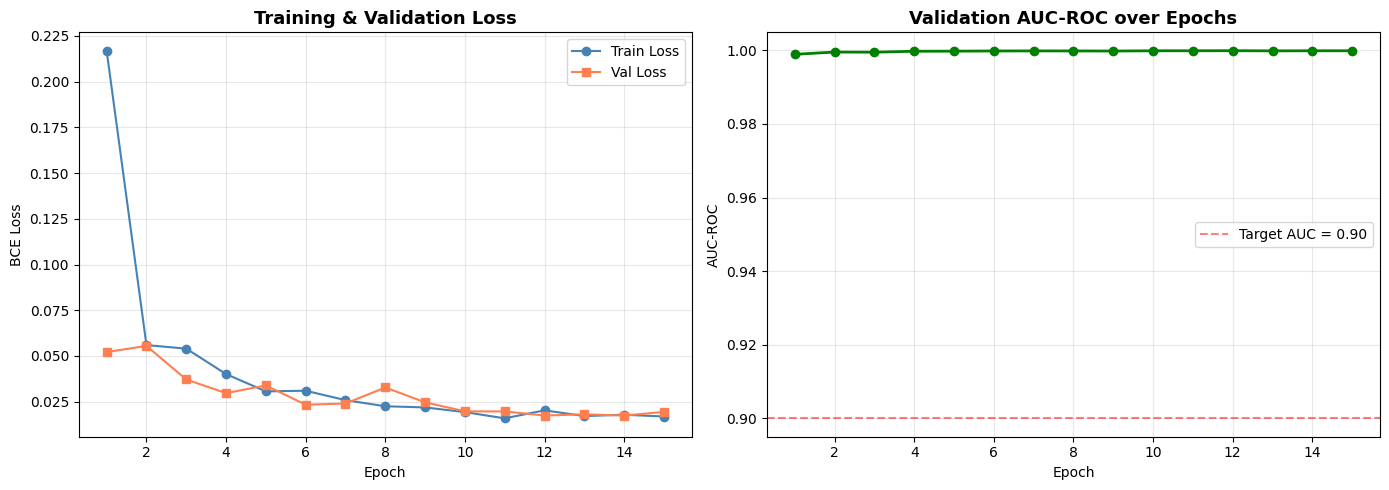

Best Validation AUC: 0.9999


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(range(1, EPOCHS+1), train_losses, marker='o', label='Train Loss', color='steelblue')
axes[0].plot(range(1, EPOCHS+1), val_losses,   marker='s', label='Val Loss',   color='coral')
axes[0].set_title('Training & Validation Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# AUC curve
axes[1].plot(range(1, EPOCHS+1), val_aucs, marker='o', color='green', linewidth=2)
axes[1].axhline(0.9, color='red', linestyle='--', alpha=0.5, label='Target AUC = 0.90')
axes[1].set_title('Validation AUC-ROC over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC-ROC')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print(f'Best Validation AUC: {max(val_aucs):.4f}')

## Step 8: Evaluate on Test Set

In [8]:
model.eval()
test_preds, test_labels = [], []

with torch.no_grad():
    for drug_a, drug_b, drug_c, triplet, labels in test_loader:
        preds = model(drug_a, drug_b, drug_c, triplet)
        test_preds.extend(preds.numpy())
        test_labels.extend(labels.numpy())

test_preds_binary = [1 if p >= 0.5 else 0 for p in test_preds]

auc      = roc_auc_score(test_labels, test_preds)
f1       = f1_score(test_labels, test_preds_binary)
accuracy = accuracy_score(test_labels, test_preds_binary)

print('=' * 45)
print('  TEST SET RESULTS — 3-Way GNN')
print('=' * 45)
print(f'  AUC-ROC:  {auc:.4f}')
print(f'  F1 Score: {f1:.4f}')
print(f'  Accuracy: {accuracy:.4f}')
print('=' * 45)
print()
print('Detailed Report:')
print(classification_report(test_labels, test_preds_binary,
                             target_names=['No Interaction', 'Interaction']))

  TEST SET RESULTS — 3-Way GNN
  AUC-ROC:  0.9999
  F1 Score: 0.9903
  Accuracy: 0.9904

Detailed Report:
                precision    recall  f1-score   support

No Interaction       0.98      1.00      0.99     10500
   Interaction       1.00      0.98      0.99     10500

      accuracy                           0.99     21000
     macro avg       0.99      0.99      0.99     21000
  weighted avg       0.99      0.99      0.99     21000



## Step 9: Confusion Matrix

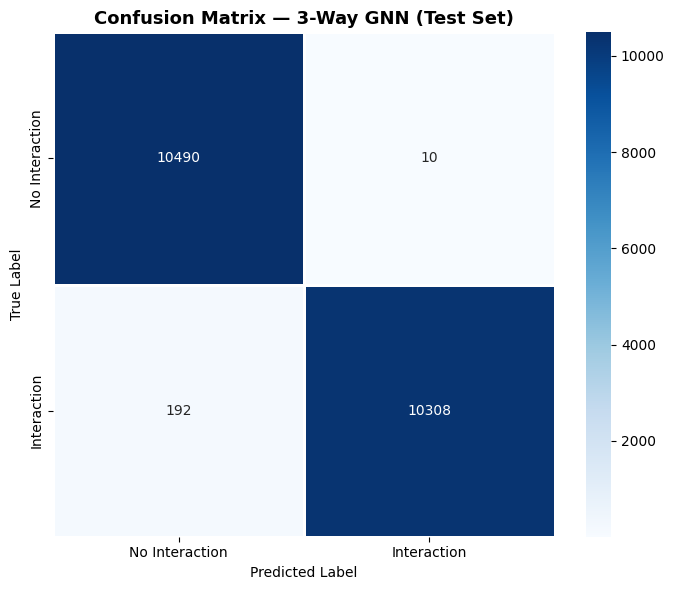

In [9]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, test_preds_binary)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Interaction', 'Interaction'],
            yticklabels=['No Interaction', 'Interaction'],
            linewidths=1, linecolor='white')
ax.set_title('Confusion Matrix — 3-Way GNN (Test Set)', fontsize=13, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## Step 10: Architecture Summary

In [10]:
print('=' * 55)
print('  3-WAY GNN ARCHITECTURE SUMMARY')
print('=' * 55)
print(f'  Model Type:           3-Way GNN with Self-Attention')
print(f'  Input:                3 drug feature vectors + triplet features')
print(f'  Drug Features:        8 per drug (centrality, CYP, severity, etc.)')
print(f'  Triplet Features:     8 (combined interaction stats)')
print(f'  Total Input Features: 32')
print(f'  Drug Encoder:         Linear(8→64) + BN + ReLU + Dropout')
print(f'  Message Passing:      Multi-Head Attention (4 heads)')
print(f'  Hidden Dimension:     64')
print(f'  Classifier:           MLP 256→128→64→1')
print(f'  Output:               Sigmoid → probability [0,1]')
print(f'  Loss:                 Binary Cross Entropy')
print(f'  Optimizer:            Adam (lr=0.001)')
print(f'  Total Parameters:     {sum(p.numel() for p in model.parameters()):,}')
print(f'  Training Data:        4,500 triplets')
print(f'  Validation Data:      4,500 triplets')
print(f'  Test Data:            21,000 triplets')
print('=' * 55)
print(f'\n  FINAL TEST RESULTS:')
print(f'  AUC-ROC:  {auc:.4f}')
print(f'  F1 Score: {f1:.4f}')
print(f'  Accuracy: {accuracy:.4f}')
print('=' * 55)

  3-WAY GNN ARCHITECTURE SUMMARY
  Model Type:           3-Way GNN with Self-Attention
  Input:                3 drug feature vectors + triplet features
  Drug Features:        8 per drug (centrality, CYP, severity, etc.)
  Triplet Features:     8 (combined interaction stats)
  Total Input Features: 32
  Drug Encoder:         Linear(8→64) + BN + ReLU + Dropout
  Message Passing:      Multi-Head Attention (4 heads)
  Hidden Dimension:     64
  Classifier:           MLP 256→128→64→1
  Output:               Sigmoid → probability [0,1]
  Loss:                 Binary Cross Entropy
  Optimizer:            Adam (lr=0.001)
  Total Parameters:     63,297
  Training Data:        4,500 triplets
  Validation Data:      4,500 triplets
  Test Data:            21,000 triplets

  FINAL TEST RESULTS:
  AUC-ROC:  0.9999
  F1 Score: 0.9903
  Accuracy: 0.9904
